# Module 9: Data Aggregation


In [ ]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import Image

import warnings
warnings.filterwarnings('ignore')

AttributeError: module 'matplotlib' has no attribute '__version_info__'

## Introduction
Data aggregation and grouping are essential techniques for summarizing and analyzing large datasets. In pandas, the groupby() method implements the split–apply–combine strategy, allowing you to split data into groups, apply functions to each group, and combine the results into a single output. These tools are especially useful for computing summary statistics, reshaping data, and performing operations across categories without manual iteration.

## Learning Objectives
- Perform data aggregation and group operations in pandas using built-in and custom functions.
- Apply the split–apply–combine workflow to summarize, transform, and filter grouped data.
- Use custom aggregation functions to solve complex analytical problems beyond simple descriptive statistics.

## Reading
- [Chapter 10](https://wesmckinney.com/book/data-aggregation)

Categorizing a dataset and applying a function to each group, whether an aggregation or transformation, is often a critical component of a data analysis workflow. After loading, merging, and preparing a dataset, you may need to compute group statistics or possibly pivot tables for reporting or visualization purposes. pandas provides a flexible groupby interface, enabling you to slice, dice, and summarize datasets in a natural way.

Groupby operations follow the **split-apply-combine** concept:
- The split step involves breaking up and grouping a DataFrame depending on the value of the specified key.
- The apply step involves computing some function, usually an aggregate, transformation, or filtering, within the individual groups.
- The combine step merges the results of these operations into an output array.


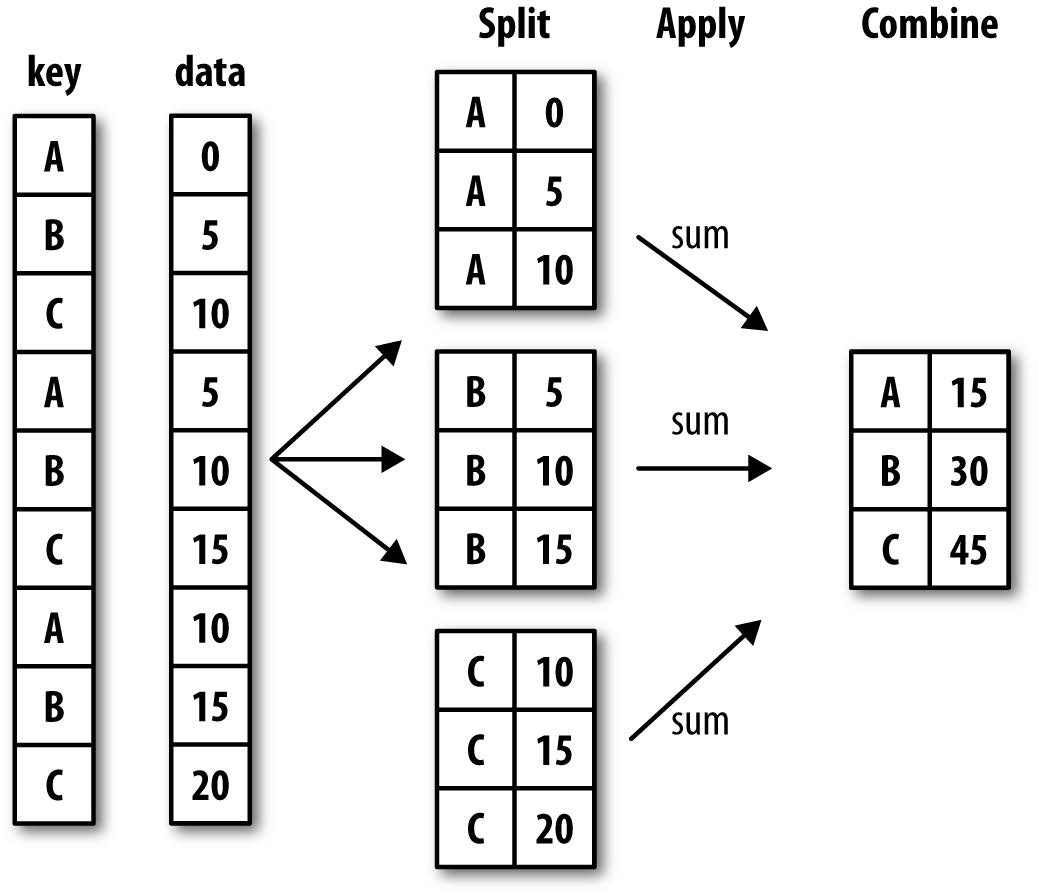

In [ ]:
Image(filename='img/split-apply-combine.jpg',width=400)

In [ ]:
df = pd.read_csv('data/GVP_Volcano_List_Holocene.csv',header=1,dtype={'Volcano Number':str})
df

,Volcano Number,Volcano Name,Country,Primary Volcano Type,Activity Evidence,Last Known Eruption,Region,Subregion,Latitude,Longitude,Elevation (m),Dominant Rock Type,Tectonic Setting
0,210010,West Eifel Volcanic Field,Germany,Maar(s),Eruption Dated,8300 BCE,Mediterranean and Western Asia,Western Europe,50.170,6.850,600,Foidite,Rift zone / Continental crust (>25 km)
1,210020,Chaine des Puys,France,Lava dome(s),Eruption Dated,4040 BCE,Mediterranean and Western Asia,Western Europe,45.775,2.970,1464,Basalt / Picro-Basalt,Rift zone / Continental crust (>25 km)
2,210030,Olot Volcanic Field,Spain,Pyroclastic cone(s),Evidence Credible,Unknown,Mediterranean and Western Asia,Western Europe,42.170,2.530,893,Trachybasalt / Tephrite Basanite,Intraplate / Continental crust (>25 km)
3,210040,Calatrava Volcanic Field,Spain,Pyroclastic cone(s),Eruption Dated,3600 BCE,Mediterranean and Western Asia,Western Europe,38.870,-4.020,1117,Basalt / Picro-Basalt,Intraplate / Continental crust (>25 km)
4,211003,Vulsini,Italy,Caldera,Eruption Observed,104 BCE,Mediterranean and Western Asia,Italy,42.600,11.930,800,Trachyte / Trachydacite,Subduction zone / Continental crust (>25 km)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1419,390120,Leskov Island,United Kingdom,Stratovolcano,Unrest / Holocene,Unknown,Antarctica,Antarctica and South Sandwich Islands,-56.656,-28.140,190,Andesite / Basaltic Andesite,Subduction zone / Oceanic crust (< 15 km)
1420,390130,Zavodovski,United Kingdom,Stratovolcano,Eruption Observed,2016 CE,Antarctica,Antarctica and South Sandwich Islands,-56.300,-27.570,551,Basalt / Picro-Basalt,Subduction zone / Oceanic crust (< 15 km)
1421,390140,Protector Seamounts,United Kingdom,Submarine,Eruption Observed,1962 CE,Antarctica,Antarctica and South Sandwich Islands,-55.912,-28.167,-55,Rhyolite,Subduction zone / Oceanic crust (< 15 km)
1422,390829,James Ross Island,Antarctica,Shield,Evidence Credible,Unknown,Antarctica,Antarctica and South Sandwich Islands,-64.150,-57.750,1630,Basalt / Picro-Basalt,Intraplate / Continental crust (>25 km)


Recall that we added a new column for the eruption date, based on the existing column 'Last Known Eruption'.

In [ ]:
# First, drop all the rows with unknown eruption date
df = df[~df['Last Known Eruption'].str.contains('Unknown')] 

# put in the 'Date' column to keep the numeric part of 'Last Known Eruption' column
# .str.split() produces a string, which is converted to integer
df['Date'] = df['Last Known Eruption'].str.split(' ',expand=True)[0].astype('int')

# put in the 'CE/BCE' column:
df['CE/BCE'] = df['Last Known Eruption'].str.split(' ',expand=True)[1].astype('str')

# update the 'Date' column based on CE/BCE
df.loc[df['CE/BCE'].str.contains('BCE'), 'Date'] = -1*df['Date']

df.head()

,Volcano Number,Volcano Name,Country,Primary Volcano Type,Activity Evidence,Last Known Eruption,Region,Subregion,Latitude,Longitude,Elevation (m),Dominant Rock Type,Tectonic Setting,Date,CE/BCE
0,210010,West Eifel Volcanic Field,Germany,Maar(s),Eruption Dated,8300 BCE,Mediterranean and Western Asia,Western Europe,50.170,6.850,600,Foidite,Rift zone / Continental crust (>25 km),-8300,BCE
1,210020,Chaine des Puys,France,Lava dome(s),Eruption Dated,4040 BCE,Mediterranean and Western Asia,Western Europe,45.775,2.970,1464,Basalt / Picro-Basalt,Rift zone / Continental crust (>25 km),-4040,BCE
3,210040,Calatrava Volcanic Field,Spain,Pyroclastic cone(s),Eruption Dated,3600 BCE,Mediterranean and Western Asia,Western Europe,38.870,-4.020,1117,Basalt / Picro-Basalt,Intraplate / Continental crust (>25 km),-3600,BCE
4,211003,Vulsini,Italy,Caldera,Eruption Observed,104 BCE,Mediterranean and Western Asia,Italy,42.600,11.930,800,Trachyte / Trachydacite,Subduction zone / Continental crust (>25 km),-104,BCE
6,211010,Campi Flegrei,Italy,Caldera,Eruption Observed,1538 CE,Mediterranean and Western Asia,Italy,40.827,14.139,458,Trachyte / Trachydacite,Subduction zone / Continental crust (>25 km),1538,CE


Suppose you want to count the number of volcanoes in each Region. Conceptually, you would take these steps:
- split the DataFrame into groups, each with all the rows corresponding to the same Region
- count the size of each group
- gather the results for each group together

In pandas, this is done via the **groupby** operation

In [ ]:
grps = df.groupby('Region')
type(grps)

pandas.core.groupby.generic.DataFrameGroupBy

Notice that what is returned is not a set of DataFrames, but a **DataFrameGroupBy** object, which essentially describes how the rows of the original dataset have been split. There are some attributes and methods available for us to access groups information.

This object is where the magic is: you can think of it as a special view of the DataFrame, which is poised to dig into the groups but does no actual computation until the aggregation is applied.

In [ ]:
# use ngroups attribute to get the number of groups
grps.ngroups

19

In [ ]:
# Use groups attribute to get groups object. The integer numbers in the list are the row number for each group.
grps.groups

{'Africa and Red Sea': [41, 42, 46, 48, 50, 53, 54, 63, 64, 66, 69, 73, 75, 83, 85, 91, 95, 106, 108, 109, 111, 112, 113, 117, 121, 122, 124, 125, 126, 127, 128, 129, 130, 131, 136, 137, 138, 139, 145, 146, 158, 160, 161], 'Alaska': [826, 829, 830, 831, 832, 833, 835, 836, 837, 838, 839, 840, 841, 842, 843, 845, 847, 848, 851, 852, 854, 855, 856, 857, 858, 859, 860, 862, 863, 867, 869, 873, 874, 875, 876, 877, 878, 880, 881, 883, 884, 885, 886, 887, 888, 889, 893, 894, 896, 897, 898, 899, 900, 901, 904, 905, 906, 907, 908], 'Antarctica': [1391, 1394, 1395, 1398, 1400, 1405, 1406, 1408, 1409, 1413, 1414, 1415, 1416, 1417, 1420, 1421], 'Atlantic Ocean': [1362, 1363, 1365, 1366, 1367, 1368, 1369, 1370, 1371, 1372, 1373, 1374, 1375, 1376, 1377, 1378, 1379, 1380, 1382, 1383, 1386, 1387, 1388, 1389, 1390], 'Canada and Western USA': [918, 920, 921, 922, 925, 926, 929, 931, 933, 934, 935, 936, 937, 938, 939, 940, 941, 942, 943, 944, 945, 946, 947, 948, 951, 952, 953, 954, 955, 956, 958, 959, 9

In [ ]:
#use size() method to compute and display group sizes.
grps.size()

Region
Africa and Red Sea                 43
Alaska                             59
Antarctica                         16
Atlantic Ocean                     25
Canada and Western USA             49
Hawaii and Pacific Ocean           27
Iceland and Arctic Ocean           29
Indonesia                          80
Japan, Taiwan, Marianas           109
Kamchatka and Mainland Asia        69
Kuril Islands                      31
Mediterranean and Western Asia     30
Melanesia and Australia            43
Middle East and Indian Ocean       20
México and Central America         49
New Zealand to Fiji                38
Philippines and SE Asia            27
South America                     115
West Indies                        12
dtype: int64

In [ ]:
# To preview the groups, we can call first() or last() to preview the result with the first or last entry.
grps.first()

,Volcano Number,Volcano Name,Country,Primary Volcano Type,Activity Evidence,Last Known Eruption,Subregion,Latitude,Longitude,Elevation (m),Dominant Rock Type,Tectonic Setting,Date,CE/BCE
Region,,,,,,,,,,,,,,
Africa and Red Sea,221010,"Tair, Jebel at",Yemen,Stratovolcano,Eruption Observed,2008 CE,Africa (northeastern) and Red Sea,15.550,41.830,244,Trachybasalt / Tephrite Basanite,Rift zone / Oceanic crust (< 15 km),2008,CE
Alaska,311020,Kiska,United States,Stratovolcano,Eruption Observed,1990 CE,Aleutian Islands,52.103,177.602,1220,Andesite / Basaltic Andesite,Subduction zone / Intermediate crust (15-25 km),1990,CE
Antarctica,390010,Buckle Island,Antarctica,Stratovolcano,Eruption Observed,1899 CE,Antarctica and South Sandwich Islands,-66.780,163.250,1239,Trachybasalt / Tephrite Basanite,Rift zone / Oceanic crust (< 15 km),1899,CE
Atlantic Ocean,381040,Pico Fracture Zone,Undersea Features,Submarine,Eruption Observed,1865 CE,Atlantic Ocean (northern),38.750,-38.080,-4200,No Data (checked),Intraplate / Oceanic crust (< 15 km),1865,CE
Canada and Western USA,320060,Edziza,Canada,Stratovolcano,Eruption Dated,950 CE,Canada,57.720,-130.630,2786,Trachyte / Trachydacite,Intraplate / Continental crust (>25 km),950,CE
Hawaii and Pacific Ocean,331010,Endeavour Segment,Canada,Submarine,Eruption Dated,3490 BCE,Pacific Ocean (northern),47.950,-129.100,-2050,Basalt / Picro-Basalt,Rift zone / Oceanic crust (< 15 km),-3490,BCE
Iceland and Arctic Ocean,370010,Snaefellsjokull,Iceland,Stratovolcano,Eruption Dated,200 CE,Iceland (western),64.800,-23.783,1446,Basalt / Picro-Basalt,Rift zone / Oceanic crust (< 15 km),200,CE
Indonesia,260010,Barren Island,India,Stratovolcano,Eruption Observed,2020 CE,Andaman Islands,12.278,93.858,354,Basalt / Picro-Basalt,Subduction zone / Continental crust (>25 km),2020,CE
"Japan, Taiwan, Marianas",281030,Unnamed,Taiwan,Submarine,Eruption Observed,1853 CE,Taiwan,24.132,121.926,-1640,No Data (checked),Subduction zone / Continental crust (>25 km),1853,CE


**.groupby( )** groups things in your DataFrame by unique values in a **Series**, for example grouping everything by 'Region'. 

Then, **.describe( )** can be used to summarize some useful statistics of each group.

In [ ]:
grps['Primary Volcano Type'].describe()

,count,unique,top,freq
Region,,,,
Africa and Red Sea,43,11,Stratovolcano,16
Alaska,59,10,Stratovolcano,40
Antarctica,16,6,Stratovolcano,9
Atlantic Ocean,25,7,Stratovolcano,10
Canada and Western USA,49,14,Stratovolcano,11
Hawaii and Pacific Ocean,27,2,Submarine,22
Iceland and Arctic Ocean,29,8,Stratovolcano,11
Indonesia,80,7,Stratovolcano,51
"Japan, Taiwan, Marianas",109,12,Stratovolcano,36


This tells us that, for example, out of 59 volcanoes in 'Alaska', 40 are 'stratovolcanoes'.

Let's go back to our question: what is the number of volcanoes of each region?

You can use the .count() method on the 'Region' column of the groupby object. It returns a pandas **Series** with the list of regions as the index.

In [ ]:
df.groupby('Region')['Region'].count()

Region
Africa and Red Sea                 43
Alaska                             59
Antarctica                         16
Atlantic Ocean                     25
Canada and Western USA             49
Hawaii and Pacific Ocean           27
Iceland and Arctic Ocean           29
Indonesia                          80
Japan, Taiwan, Marianas           109
Kamchatka and Mainland Asia        69
Kuril Islands                      31
Mediterranean and Western Asia     30
Melanesia and Australia            43
Middle East and Indian Ocean       20
México and Central America         49
New Zealand to Fiji                38
Philippines and SE Asia            27
South America                     115
West Indies                        12
Name: Region, dtype: int64

For visualization we can use a bar plot. Note that Series or DataFrame have built-in plot function, which is a wrapper of the matplotlib plot function.

Text(0, 0.5, 'Count')

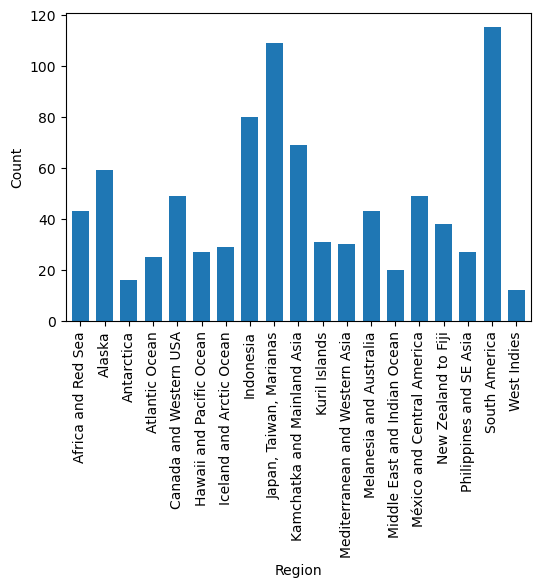

In [ ]:
dfg = df.groupby('Region')['Region'].count()
ax = dfg.plot(kind='bar',width=.7,figsize=(6,4))
ax.set_ylabel('Count')

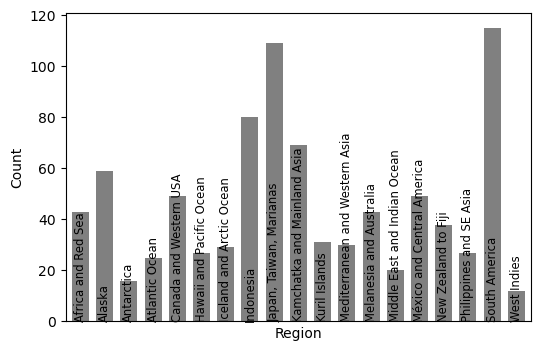

In [ ]:
# We can do some customizations.

dfg = df.groupby('Region')['Region'].count()
ax = dfg.plot(kind='bar',width=.7,figsize=(6,4),color='gray')
ax.set_ylabel('Count')
ax.set_xticks([])

for i, idx in enumerate(dfg.index):
    ax.text(i,0,idx,va='bottom',c='k',ha='center',rotation=90,size='small')
    
plt.show()

What if we want to find out the highest volcano in each region?

In [ ]:
df.groupby('Region')['Elevation (m)'].max()

Region
Africa and Red Sea                4565
Alaska                            5005
Antarctica                        3794
Atlantic Ocean                    3715
Canada and Western USA            4392
Hawaii and Pacific Ocean          4205
Iceland and Arctic Ocean          2197
Indonesia                         3800
Japan, Taiwan, Marianas           3776
Kamchatka and Mainland Asia       5808
Kuril Islands                     2285
Mediterranean and Western Asia    5642
Melanesia and Australia           2334
Middle East and Indian Ocean      5670
México and Central America        5564
New Zealand to Fiji               2797
Philippines and SE Asia           2865
South America                     6879
West Indies                       1467
Name: Elevation (m), dtype: int64

When is the most recent eruption in each country?

In [ ]:
df.groupby('Country')['Date'].max()

Country
Antarctica            2020
Argentina             1822
Armenia              -1900
Armenia-Azerbaijan    -778
Australia             2020
                      ... 
United Kingdom        2020
United States         2020
Vanuatu               2020
Vietnam               1923
Yemen                 2013
Name: Date, Length: 79, dtype: int64

The above methods of groupby objects, namely count() and max(), are called **aggregation** statistics. 

There are a list of aggregation methods:
    
|Function name| Description|
|-------------|------------|
|count| Number of non-NA values in the group|
|sum| Sum of non-NA values|
|mean| Mean of non-NA values|
|median| Arithmetic median of non-NA values|
|std, var| Unbiased (n – 1 denominator) standard deviation and variance|
|min, max| Minimum and maximum of non-NA values|
|prod| Product of non-NA values|
|first, last| First and last non-NA values|

You can also define your own function and use as aggregation method. For instance, what is the height difference between the lowest and highest volcano within each region?

To use your own aggregation functions, pass any function that aggregates an array to the aggregate or **agg** method:

In [ ]:
def max_minus_min(arr):
    return arr.max()-arr.min()

df.groupby('Region')['Elevation (m)'].agg(max_minus_min)

Region
Africa and Red Sea                4613
Alaska                            4914
Antarctica                        3849
Atlantic Ocean                    7915
Canada and Western USA            4432
Hawaii and Pacific Ocean          7205
Iceland and Arctic Ocean          5997
Indonesia                         3805
Japan, Taiwan, Marianas           7876
Kamchatka and Mainland Asia       6108
Kuril Islands                     2787
Mediterranean and Western Asia    6421
Melanesia and Australia           3634
Middle East and Indian Ocean      6320
México and Central America        5232
New Zealand to Fiji               4197
Philippines and SE Asia           2889
South America                     6722
West Indies                       1652
Name: Elevation (m), dtype: int64

To find the most common rock type of each region:

In [ ]:
def most_common(arr):
    return arr.value_counts().index[0]

df.groupby('Region')['Dominant Rock Type'].agg(most_common)

Region
Africa and Red Sea                       Basalt / Picro-Basalt
Alaska                            Andesite / Basaltic Andesite
Antarctica                               Basalt / Picro-Basalt
Atlantic Ocean                           Basalt / Picro-Basalt
Canada and Western USA                   Basalt / Picro-Basalt
Hawaii and Pacific Ocean                 Basalt / Picro-Basalt
Iceland and Arctic Ocean                 Basalt / Picro-Basalt
Indonesia                         Andesite / Basaltic Andesite
Japan, Taiwan, Marianas           Andesite / Basaltic Andesite
Kamchatka and Mainland Asia              Basalt / Picro-Basalt
Kuril Islands                     Andesite / Basaltic Andesite
Mediterranean and Western Asia    Andesite / Basaltic Andesite
Melanesia and Australia           Andesite / Basaltic Andesite
Middle East and Indian Ocean             Basalt / Picro-Basalt
México and Central America        Andesite / Basaltic Andesite
New Zealand to Fiji               Andesite / Bas

In the above, the **value_counts()** method is applied to the 'Dominant Rock Type' column of each group, and returns a **Series** containing counts of unique values. 

The Series is in descending order so that the first element is the most frequently-occurring element. For example,

In [ ]:
df['Dominant Rock Type'].value_counts()

Dominant Rock Type
Andesite / Basaltic Andesite                386
Basalt / Picro-Basalt                       265
Dacite                                       63
Trachybasalt / Tephrite Basanite             39
Rhyolite                                     35
Trachyte / Trachydacite                      28
Trachyandesite / Basaltic Trachyandesite     18
No Data (checked)                            16
Foidite                                       6
Phonolite                                     6
Phono-tephrite /  Tephri-phonolite            2
Name: count, dtype: int64

In the above, the aggregation was performed on a specified column. Sometimes it is desirable to include all columns from the DataFrame.

In [ ]:
def most_common(arr):
    return arr.value_counts().index[0]

df.groupby('Region').agg(most_common)

,Volcano Number,Volcano Name,Country,Primary Volcano Type,Activity Evidence,Last Known Eruption,Subregion,Latitude,Longitude,Elevation (m),Dominant Rock Type,Tectonic Setting,Date,CE/BCE
Region,,,,,,,,,,,,,,
Africa and Red Sea,221010,"Tair, Jebel at",Ethiopia,Stratovolcano,Eruption Observed,2020 CE,Africa (northeastern) and Red Sea,15.550,41.830,600,Basalt / Picro-Basalt,Rift zone / Continental crust (>25 km),2020,CE
Alaska,311020,Kiska,United States,Stratovolcano,Eruption Observed,1912 CE,Aleutian Islands,52.103,177.602,1220,Andesite / Basaltic Andesite,Subduction zone / Continental crust (>25 km),1912,CE
Antarctica,390010,Buckle Island,Antarctica,Stratovolcano,Eruption Observed,2020 CE,Antarctica and South Sandwich Islands,-66.780,163.250,1239,Basalt / Picro-Basalt,Intraplate / Continental crust (>25 km),2020,CE
Atlantic Ocean,381040,Pico Fracture Zone,Portugal,Stratovolcano,Eruption Observed,1720 CE,Azores,37.770,-38.080,-4200,Basalt / Picro-Basalt,Rift zone / Oceanic crust (< 15 km),1720,CE
Canada and Western USA,320060,Edziza,United States,Stratovolcano,Eruption Dated,950 CE,USA (Oregon),57.720,-121.820,2786,Basalt / Picro-Basalt,Subduction zone / Continental crust (>25 km),950,CE
Hawaii and Pacific Ocean,331010,Endeavour Segment,Undersea Features,Submarine,Eruption Observed,1996 CE,Pacific Ocean (eastern),47.950,-129.100,-39,Basalt / Picro-Basalt,Rift zone / Oceanic crust (< 15 km),1996,CE
Iceland and Arctic Ocean,370010,Snaefellsjokull,Iceland,Stratovolcano,Eruption Observed,200 CE,Iceland (northeastern),64.050,-23.783,1490,Basalt / Picro-Basalt,Rift zone / Oceanic crust (< 15 km),200,CE
Indonesia,260010,Sumbing,Indonesia,Stratovolcano,Eruption Observed,2020 CE,Java,-6.770,93.858,354,Andesite / Basaltic Andesite,Subduction zone / Continental crust (>25 km),2020,CE
"Japan, Taiwan, Marianas",281030,Unnamed,Japan,Stratovolcano,Eruption Observed,2020 CE,Honshu,43.418,140.303,857,Andesite / Basaltic Andesite,Subduction zone / Continental crust (>25 km),2020,CE


You can also pass a list of functions to the agg method. It will return a **DataFrame** with column names taken from the functions.

In [ ]:
df.groupby('Region')['Elevation (m)'].agg(['max','min',max_minus_min])

,max,min,max_minus_min
Region,,,
Africa and Red Sea,4565,-48,4613
Alaska,5005,91,4914
Antarctica,3794,-55,3849
Atlantic Ocean,3715,-4200,7915
Canada and Western USA,4392,-40,4432
Hawaii and Pacific Ocean,4205,-3000,7205
Iceland and Arctic Ocean,2197,-3800,5997
Indonesia,3800,-5,3805
"Japan, Taiwan, Marianas",3776,-4100,7876


You can specify your own column names for the output.

In [ ]:
df.groupby('Region')['Elevation (m)'].agg(
    ELV_max='max',
    ELV_min='min',
    ELV_range=max_minus_min
)

,ELV_max,ELV_min,ELV_range
Region,,,
Africa and Red Sea,4565,-48,4613
Alaska,5005,91,4914
Antarctica,3794,-55,3849
Atlantic Ocean,3715,-4200,7915
Canada and Western USA,4392,-40,4432
Hawaii and Pacific Ocean,4205,-3000,7205
Iceland and Arctic Ocean,2197,-3800,5997
Indonesia,3800,-5,3805
"Japan, Taiwan, Marianas",3776,-4100,7876


What if we want to calculate different statistics depending on the column, for example, the most recent eruption date and the average elevation within each region?

In [ ]:
df.groupby('Region')[['Date','Elevation (m)']].agg({
    'Date':'max',
    'Elevation (m)':'mean',
    })

,Date,Elevation (m)
Region,,
Africa and Red Sea,2020,1891.511628
Alaska,2020,1614.457627
Antarctica,2020,1544.250000
Atlantic Ocean,2015,924.400000
Canada and Western USA,2008,2333.061224
Hawaii and Pacific Ocean,2018,-1062.740741
Iceland and Arctic Ocean,2015,858.172414
Indonesia,2020,1928.387500
"Japan, Taiwan, Marianas",2020,1064.211009


In all of the examples above, the aggregated data comes back with an index composed from the unique group key combinations. 

You can disable this behavior in most cases by passing as_index=False to groupby.

In [ ]:
df.groupby('Region',as_index=False)[['Date','Elevation (m)']].agg({
    'Date':'max',
    'Elevation (m)':'mean',
    })

,Region,Date,Elevation (m)
0,Africa and Red Sea,2020,1891.511628
1,Alaska,2020,1614.457627
2,Antarctica,2020,1544.250000
3,Atlantic Ocean,2015,924.400000
4,Canada and Western USA,2008,2333.061224
5,Hawaii and Pacific Ocean,2018,-1062.740741
6,Iceland and Arctic Ocean,2015,858.172414
7,Indonesia,2020,1928.387500
8,"Japan, Taiwan, Marianas",2020,1064.211009
9,Kamchatka and Mainland Asia,2020,1908.782609


You can also groupby on multiple columns:

In [ ]:
df.groupby(['Region','Primary Volcano Type'])[['Date','Elevation (m)']].agg({
    'Date':'max',
    'Elevation (m)':'mean',
    })

Date  Elevation (m)
Region             Primary Volcano Type                     
Africa and Red Sea Caldera               1450         2614.0
                   Caldera(s)            1820         1380.0
                   Explosion crater(s)   2011          -48.0
                   Fissure vent(s)       2008          492.0
                   Pyroclastic cone      1900         2343.0
...                                       ...            ...
West Indies        Caldera               1766          777.0
                   Complex                920         1387.0
                   Stratovolcano         2013         1072.5
                   Stratovolcano(es)     1997         1224.0
                   Submarine             2017         -185.0

[172 rows x 2 columns]

The above examples use a single or multiple columns of the DataFrame itself as the grouping key. However, the grouping key can take many forms, and the keys do not have to be all of the same type:
- A list or array of values that is the same length as the axis being grouped
- A value indicating a column name in a DataFrame
- A dict or Series giving a correspondence between the values on the axis being grouped and the group names
- A function to be invoked on the axis index or the individual labels in the index

For example, you want to count the number of volcanoes for every 10-degree longitude bands starting from -180 to 180 degrees.

In [ ]:
binEdges = np.arange(-180,190,10)
bins = pd.cut(df['Longitude'],binEdges) # cut df into different bins by longitude
Nlon = df['Longitude'].groupby(bins).count()
Nlon.name = 'Count'
Nlon

Longitude
(-180, -170]    37
(-170, -160]    17
(-160, -150]    28
(-150, -140]     7
(-140, -130]     7
(-130, -120]    31
(-120, -110]    23
(-110, -100]    13
(-100, -90]     31
(-90, -80]      24
(-80, -70]      87
(-70, -60]      31
(-60, -50]       1
(-50, -40]       0
(-40, -30]       2
(-30, -20]      29
(-20, -10]      26
(-10, 0]         3
(0, 10]          5
(10, 20]        12
(20, 30]        10
(30, 40]        30
(40, 50]        30
(50, 60]         2
(60, 70]         0
(70, 80]         4
(80, 90]         2
(90, 100]       11
(100, 110]      21
(110, 120]      19
(120, 130]      74
(130, 140]      46
(140, 150]      77
(150, 160]      72
(160, 170]      39
(170, 180]      20
Name: Count, dtype: int64

The **pd.cut()** function is used to cut Series or DataFrame when you need to segment and sort data values into bins. This function is also useful for going from a continuous variable to a categorical variable. For example, cut could convert ages to groups of age ranges. Supports binning into an equal number of bins, or a pre-specified array of bins.

More info: https://pandas.pydata.org/docs/reference/api/pandas.cut.html

Text(0.5, 0, 'Count')

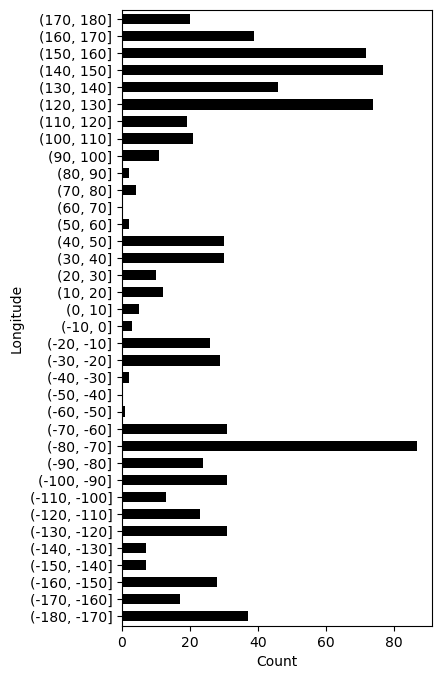

In [ ]:
ax = Nlon.plot(kind='barh',width=.6,color='k',figsize=(4,8))
ax.set_xlabel('Count')